TDA Pipeline (W=250):   0%|          | 0/47745 [00:00<?, ?it/s]

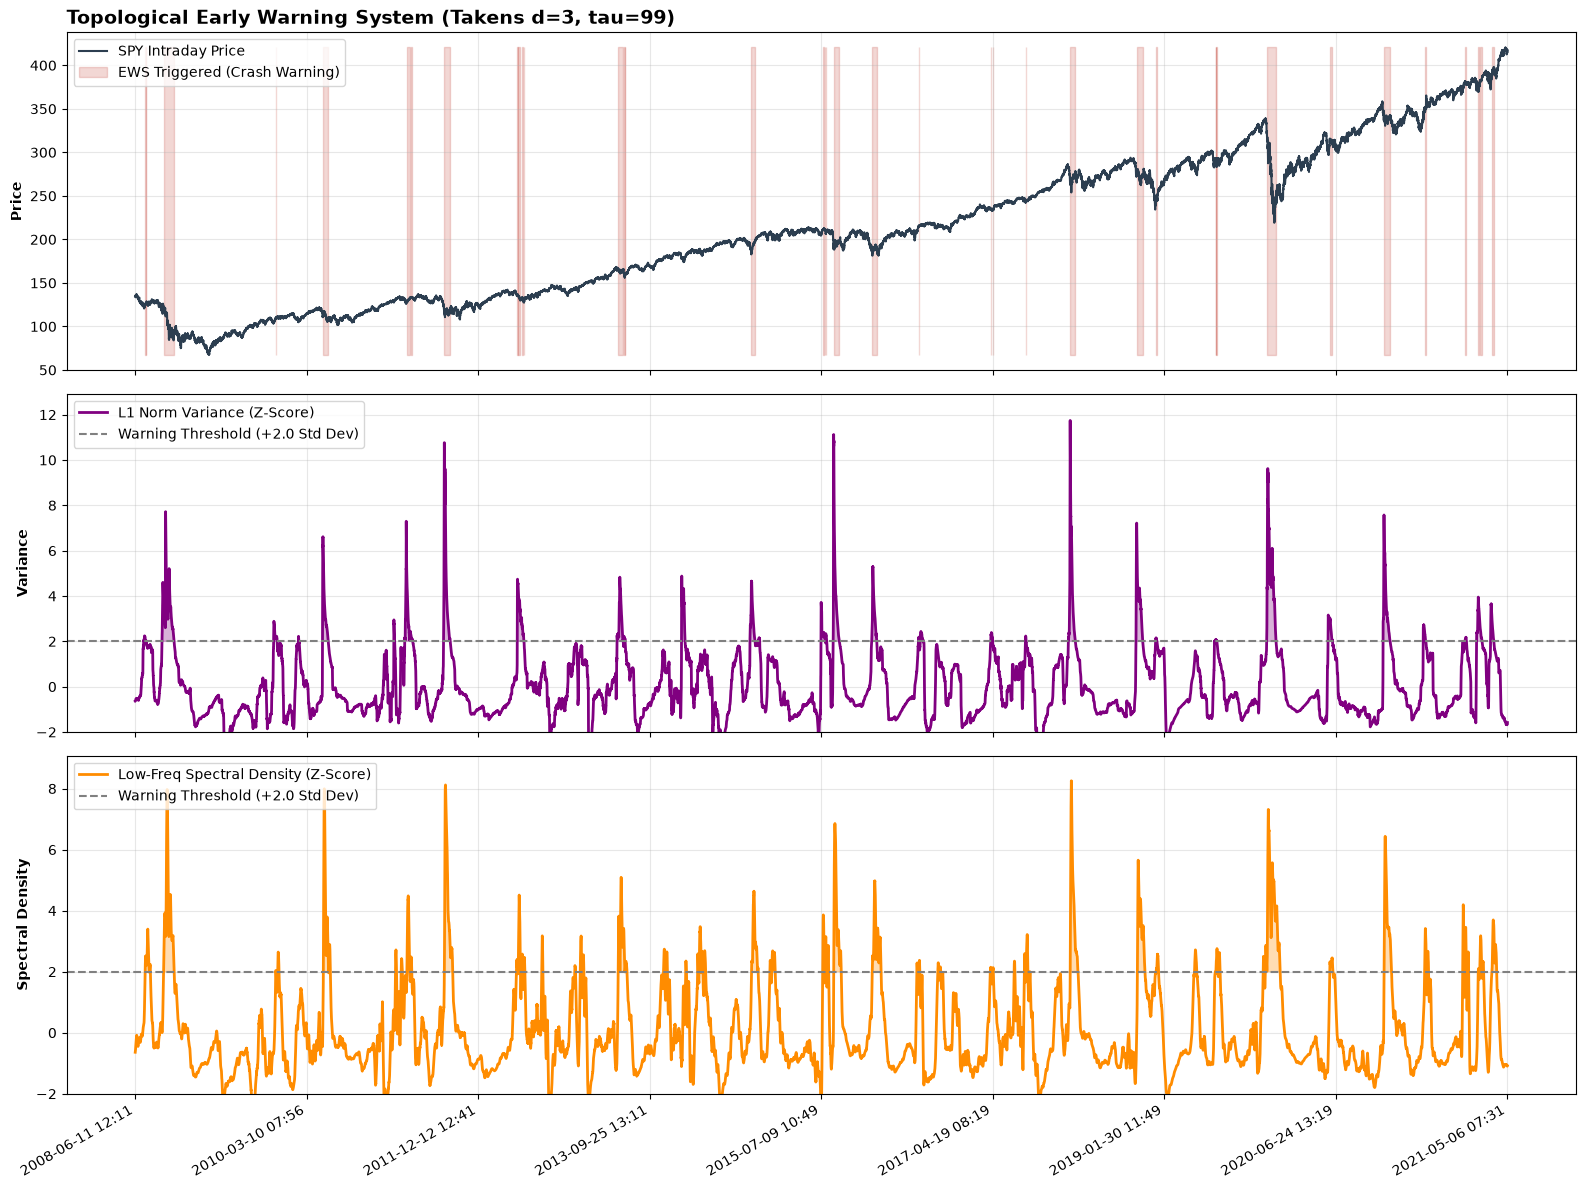

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df.index = pd.to_datetime(df.index, errors='coerce')
df.sort_index(inplace=True)

df_clean = df[~df.index.duplicated(keep='last')].copy()

start = '2008-01-01'
end = '2021-12-31'
df_sample = df_clean.loc[start:end].copy() 

df_sample['log_ret'] = np.log(df_sample['close'] / df_sample['close'].shift(1))
df_sample.dropna(inplace=True)
data_array = df_sample['log_ret'].values


embedder = SingleTakensEmbedding(parameters_type="search", time_delay=100, dimension=5, stride=1)
embedder.fit(data_array)
embedded_data = embedder.transform(data_array)

w_size = 250
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(embedded_data) - w_size
landscape_norms = []
window_dates = []


eval_step = 30

for i in tqdm(range(0, n_windows, eval_step), desc=f"TDA Pipeline (W={w_size})"):
    window_data = embedded_data[i : i+w_size]
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
        
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(df_sample.index[i + w_size])

norms_series = pd.Series(landscape_norms, index=window_dates)


eval_step = 30

# 10000/390 = 25,6 trading days
ews_window_minutes = 10000 
rolling_elements = max(1, ews_window_minutes // eval_step)

rolling_variance = norms_series.rolling(window=rolling_elements).var()

def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < rolling_elements:
        return np.nan
    
    segment_length = min(250, len(valid_data) // 2)
    freqs, psd = welch(valid_data, nperseg=segment_length) 
    
    low_freq_mask = freqs < np.percentile(freqs, 25)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=rolling_elements).apply(low_freq_spectral_density, raw=True)


z_score_window = rolling_elements * 3 

var_z = (rolling_variance - rolling_variance.rolling(window=z_score_window).mean()) / rolling_variance.rolling(window=z_score_window).std()
spec_z = (rolling_spectrum - rolling_spectrum.rolling(window=z_score_window).mean()) / rolling_spectrum.rolling(window=z_score_window).std()

THRESHOLD = 2.0 

composite_alarm = (var_z > THRESHOLD) & (spec_z > THRESHOLD)


valid_idx = var_z.dropna().index
price_data = df_sample.loc[valid_idx, 'close']
var_data = var_z.loc[valid_idx]
spec_data = spec_z.loc[valid_idx]
alarm_data = composite_alarm.loc[valid_idx]
x_indices = np.arange(len(valid_idx))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_alarm = '#c0392b'

ax1.plot(x_indices, price_data.values, color='#2c3e50', linewidth=1.5, label='SPY Intraday Price')
ax1.fill_between(x_indices, price_data.min(), price_data.max(), 
                 where=alarm_data.values, color=color_alarm, alpha=0.2, label='EWS Triggered (Crash Warning)')
ax1.set_ylabel('Price', fontweight='bold')
ax1.set_title(f'Topological Early Warning System (Takens d={embedder.dimension_}, tau={embedder.time_delay_})', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

ax2.plot(x_indices, var_data.values, color='purple', linewidth=2.0, label='L1 Norm Variance (Z-Score)')
ax2.axhline(y=THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'Warning Threshold (+{THRESHOLD} Std Dev)')
ax2.fill_between(x_indices, var_data.values, THRESHOLD, where=(var_data.values > THRESHOLD), color='purple', alpha=0.3)
ax2.set_ylabel('Variance', fontweight='bold')
ax2.set_ylim([-2, max(5, var_data.max() * 1.1)])
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

ax3.plot(x_indices, spec_data.values, color='darkorange', linewidth=2.0, label='Low-Freq Spectral Density (Z-Score)')
ax3.axhline(y=THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'Warning Threshold (+{THRESHOLD} Std Dev)')
ax3.fill_between(x_indices, spec_data.values, THRESHOLD, where=(spec_data.values > THRESHOLD), color='darkorange', alpha=0.3)
ax3.set_ylabel('Spectral Density', fontweight='bold')
ax3.set_ylim([-2, max(5, spec_data.max() * 1.1)]) 
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

num_ticks = 8
tick_spacing = max(1, len(valid_idx) // num_ticks)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

formatted_dates = [d.strftime('%Y-%m-%d %H:%M') for d in valid_idx]
def format_date(x, pos=None):
    if 0 <= int(x) < len(formatted_dates):
        return formatted_dates[int(x)]
    return ""

ax3.xaxis.set_major_formatter(ticker.FuncFormatter(format_date))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(f'from_{start}_to_{end}_topological_ews_final_{w_size}_{ews_window_minutes}_12rolling.png', dpi=300)
plt.show()